In [ ]:
import os
from torchvision import transforms
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import time
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from torchvision import transforms
from collections import Counter
from tqdm import tqdm
import json
from PIL import Image, ImageOps

from common.evaluate import evaluate_test_set, print_test_results

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = F.relu(out)
        return out


class BottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BottleneckBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(
            out_channels, out_channels * self.expansion, kernel_size=1, bias=False
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)  # 이전 conv1의 출력을 사용
        out = self.bn2(out)
        out = F.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out += identity
        out = F.relu(out)
        return out


class CustomResNet(nn.Module):
    def __init__(self, block, layers, num_classes=15):
        super(CustomResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels,
                    out_channels * block.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


def CustomResNet101(num_classes=15):
    """Custom implementation of ResNet-101."""
    return CustomResNet(BottleneckBlock, [3, 4, 23, 3], num_classes=num_classes)

한글 폰트 설정 완료 : AppleGothic


In [2]:
class CustomDataset(Dataset):
    def __init__(self, label_folder, image_folder, transform=None):

        self.label_folder = label_folder
        self.image_folder = image_folder
        self.transform = transform
        self.identifiers = []  # 각 데이터의 identifier
        self.images = []  # 이미지 데이터
        self.labels = []  # 라벨
        self.label_counts = Counter()  # 클래스별 데이터 개수
        self.diagnosis_to_label = {
            "광선각화증": 0,
            "기저세포암": 1,
            "멜라닌세포모반": 2,
            "보웬병": 3,
            "비립종": 4,
            "사마귀": 5,
            "악성흑색종": 6,
            "지루각화증": 7,
            "편평세포암": 8,
            "표피낭종": 9,
            "피부섬유종": 10,
            "피지샘증식증": 11,
            "혈관종": 12,
            "화농 육아종": 13,
            "흑색점": 14,
        }

        self._load_data()

    def _load_data(self):
        """
        JSON 파일에서 데이터를 로드하고 이미지 및 라벨을 저장
        """
        all_json_files = []
        for root, _, files in os.walk(self.label_folder):
            for json_file in files:
                if json_file.endswith(".json"):
                    all_json_files.append((root, json_file))

        # JSON 파일 순회
        for root, json_file in tqdm(all_json_files, desc="Loading data", unit="file"):
            json_file_path = os.path.join(root, json_file)
            with open(json_file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
                for annotation in data["annotations"]:
                    diagnosis_name = annotation["diagnosis_info"]["diagnosis_name"]
                    identifier = annotation["identifier"]

                    # 고정된 매핑에서 해당 진단명을 탐색
                    if diagnosis_name not in self.diagnosis_to_label:
                        print(
                            f"Unknown diagnosis found: {diagnosis_name}. Skipping this entry."
                        )
                        continue

                    label = self.diagnosis_to_label[diagnosis_name]

                    img_path = os.path.join(
                        self.image_folder, annotation["bbox"]["file_path"]
                    )

                    try:
                        image = Image.open(img_path).convert("RGB")

                        if self.transform:
                            image = self.transform(image)

                        self.images.append(image)
                        self.identifiers.append(identifier)
                        self.labels.append(label)
                        self.label_counts[diagnosis_name] += 1
                    except (FileNotFoundError, OSError) as e:
                        print(f"이미지를 읽을 수 없습니다: {img_path}. 오류: {e}")
                        continue

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

    def get_label_mappings(self):
        """
        클래스 번호와 진단명을 매핑하여 반환
        """
        return self.diagnosis_to_label

    def get_label_counts(self):
        """
        각 클래스별 데이터 개수를 반환
        """
        return self.label_counts

In [ ]:
# 경로 설정
BASE_DIR = "./"  # 프로젝트 루트 디렉토리 경로

# 학습, 검증, 테스트 데이터 경로
TRAIN_LABEL_DIR = os.path.join(
    BASE_DIR, "data/train", "라벨링데이터"
)  # 학습 라벨 데이터 경로
TRAIN_IMAGE_DIR = os.path.join(
    BASE_DIR, "data/train", "원천데이터"
)  # 학습 이미지 데이터 경로

VAL_LABEL_DIR = os.path.join(
    BASE_DIR, "data/val", "라벨링데이터"
)  # 검증 라벨 데이터 경로
VAL_IMAGE_DIR = os.path.join(
    BASE_DIR, "data/val", "원천데이터"
)  # 검증 이미지 데이터 경로

TEST_LABEL_DIR = os.path.join(
    BASE_DIR, "data/test", "라벨링데이터"
)  # 테스트 라벨 데이터 경로
TEST_IMAGE_DIR = os.path.join(
    BASE_DIR, "data/test", "원천데이터"
)  # 테스트 이미지 데이터 경로

# 로그 및 모델 저장 경로
LOG_DIR = os.path.join(BASE_DIR, "logs")
MODEL_DIR = os.path.join(BASE_DIR, "model")

# 모델 파라미터
NUM_CLASSES = 15  # 클래스 수
DROPOUT_RATE = 0.5  # 드롭아웃 비율
BATCH_SIZE = 32  # 배치 크기
LEARNING_RATE = 0.001  # 학습률
EPOCHS = 100  # 기본 에포크 수
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # GPU 사용 여부

# 클래스 이름 정의 (고정된 순서)
CLASS_NAMES = [
    "광선각화증",
    "기저세포암",
    "멜라닌세포모반",
    "보웬병",
    "비립종",
    "사마귀",
    "악성흑색종",
    "지루각화증",
    "편평세포암",
    "표피낭종",
    "피부섬유종",
    "피지샘증식증",
    "혈관종",
    "화농 육아종",
    "흑색점",
]

# Transform 설정
TRANSFORM = transforms.Compose(
    [
        transforms.Resize((256, 256)),  # 이미지 크기 조정
        transforms.ToTensor(),  # 텐서 변환
    ]
)

criterion = nn.CrossEntropyLoss()

# 한글 폰트 설정 함수
def set_korean_font():
    font_path = None
    if os.name == "nt":  # Windows
        font_path = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕
    elif os.name == "posix":  # MacOS or Linux
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"  # 나눔고딕
    if font_path and os.path.exists(font_path):
        fontprop = fm.FontProperties(fname=font_path)
        plt.rcParams["font.family"] = fontprop.get_name()
        print(f"Font set to: {fontprop.get_name()}")
    else:
        print("폰트를 찾을 수 없습니다. 시스템에 한글 폰트를 설치해주세요.")


# 한글 폰트 설정 실행
set_korean_font()

폰트를 찾을 수 없습니다. 시스템에 한글 폰트를 설치해주세요.


Starting evaluation...


Loading data: 100%|██████████| 1500/1500 [00:12<00:00, 123.67file/s]


Testing:   0%|          | 0/47 [00:00<?, ?it/s]


Baseline_ResNet - Final Test Results
Test Loss: 0.1187
Test Accuracy (Top-1): 0.9627
Test Accuracy (Top-3): 0.9967
Test F1-Score: 0.9628
Test AUROC: 0.9939


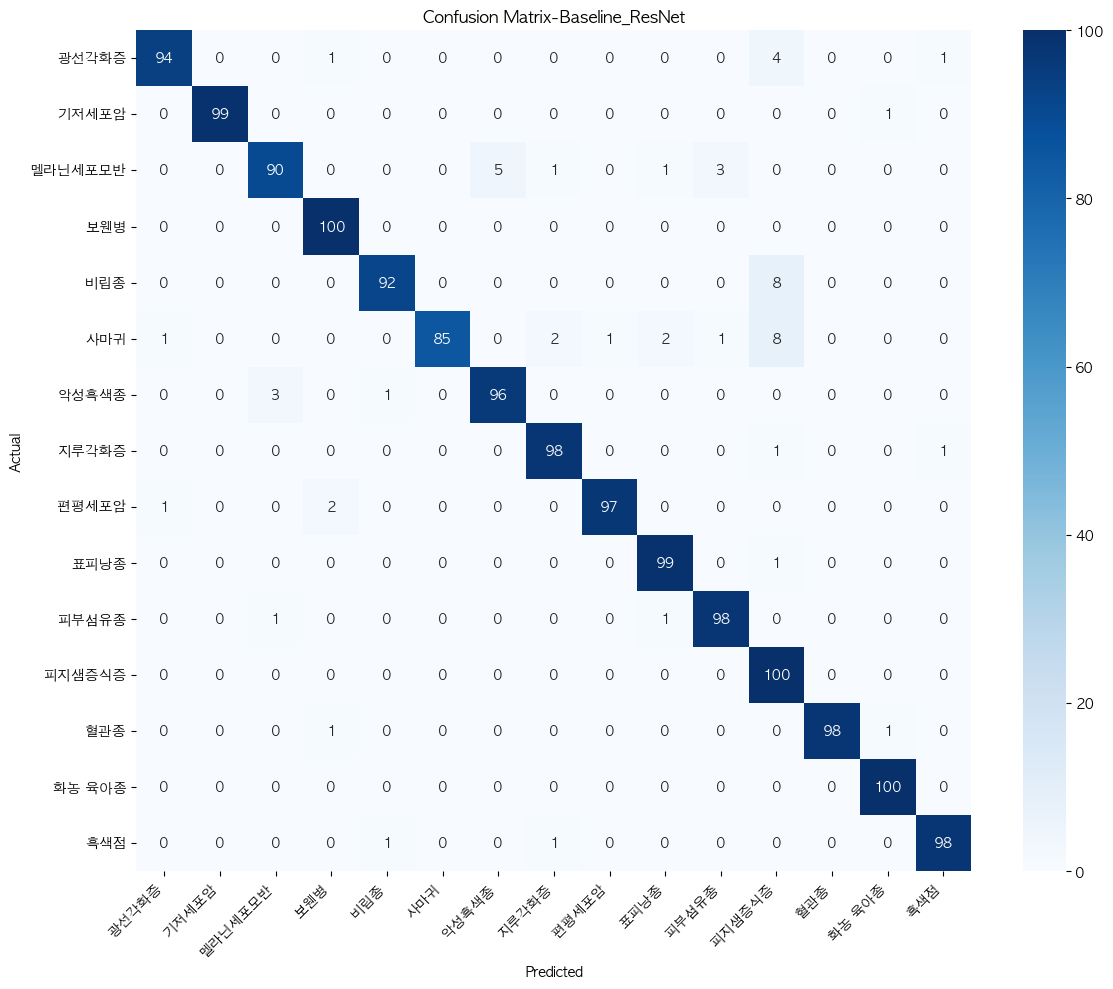

Evaluation complete.


In [ ]:
from seaborn.rcmod import reset_defaults


def calculate_top_k_accuracy(outputs, labels, k=3):

    _, top_k_preds = outputs.topk(k, dim=1)
    correct = top_k_preds.eq(labels.view(-1, 1).expand_as(top_k_preds))
    return correct.sum().item()


def evaluate_model():
    # 데이터 로드
    test_dataset = CustomDataset(
        label_folder=TEST_LABEL_DIR, image_folder=TEST_IMAGE_DIR, transform=TRANSFORM
    )

    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # 모델 로드
    model = CustomResNet101(NUM_CLASSES)
    checkpoint_path = os.path.join(MODEL_DIR, "baseline_best_model.pth.tar")
    checkpoint = torch.load(checkpoint_path, map_location=torch.device("cpu"))
    state_dict = checkpoint["state_dict"] if isinstance(checkpoint, dict) and "state_dict" in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.to(DEVICE)

    results = evaluate_test_set(model, test_loader, criterion, DEVICE)

    print(f"\n{'='*60}")
    print(f"Baseline_ResNet - Final Test Results")
    print(f"{'='*60}")
    print(f"Test Loss: {results['test_loss']:.4f}")
    print(f"Test Accuracy (Top-1): {results['test_accuracy']:.4f}")
    print(f"Test Accuracy (Top-3): {results['test_top3_accuracy']:.4f}")
    print(f"Test F1-Score: {results['test_f1_score']:.4f}")
    print(f"Test AUROC: {results['test_auroc']:.4f}")
    print(f"{'='*60}")

    # 혼동 행렬 시각화
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(results["test_labels"], results["test_predictions"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    plt.title(f"Confusion Matrix-Baseline_ResNet")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(
        os.path.join(LOG_DIR, f"confusion_matrix_Baseline_ResNet.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()  # 이미지를 화면에 표시
    plt.close()

if __name__ == "__main__":
    print("Starting evaluation...")
    evaluate_model()
    print("Evaluation complete.")